# Structural causal models

In the previous notebook, we worked with a simple setting: a single treatment, a confounder, and an outcome. This allowed us to build intuition around Simpson’s paradox, potential outcomes, and adjustment.

This notebook moves to a more general and realistic setting: **observational data with many interacting variables**.

The central tool here is the **Directed Acyclic Graph (DAG)**, which provides a structured way to represent causal assumptions. Rather than reasoning about isolated variables, we model systems of variables and the directional relationships between them.

This naturally leads to **Structural Causal Models (SCMs)**, where each variable is generated by a structural equation influenced by its parents in the graph.

In [ ]:
import networkx as nx
from causallearn.graph.GraphNode import GraphNode
from causallearn.graph.GeneralGraph import GeneralGraph
from causallearn.utils.DAG2CPDAG import dag2cpdag
import matplotlib.pyplot as plt


def nx_to_causallearn_graph(nx_dag):
    # Convert a NetworkX directed graph (DAG) into a causal-learn GeneralGraph

    # Create GraphNode objects for each node in the NetworkX graph snd Initialise causal-learn graph with these nodes
    nodes = {n: GraphNode(str(n)) for n in nx_dag.nodes()}
    graph = GeneralGraph(list(nodes.values()))
    
    # Add directed edges to the causal-learn graph
    for u, v in nx_dag.edges():
        graph.add_directed_edge(nodes[u], nodes[v])
    
    return graph


# Define a example DAG in NetworkX
dag = nx.DiGraph()
edges = [('A', 'B'), ('A', 'C'), ('A', 'D'), ('D', 'C'), ('B', 'E'), ('E', 'C'), ('B', 'D')]
#edges = [('Severity', 'Recovery'), ('Dosage', 'Recovery')]
dag.add_edges_from(edges)

# Convert to causal-learn graph format
cl_graph = nx_to_causallearn_graph(dag)

# Convert DAG to CPDAG
cpdag = dag2cpdag(cl_graph)

# Print CPDAG edges for inspection
print("CPDAG edges:")
for edge in cpdag.get_graph_edges():
    print(edge)

CPDAG edges:
A --- B
A --> C
A --- D
B --- D
B --- E
D --> C
E --> C


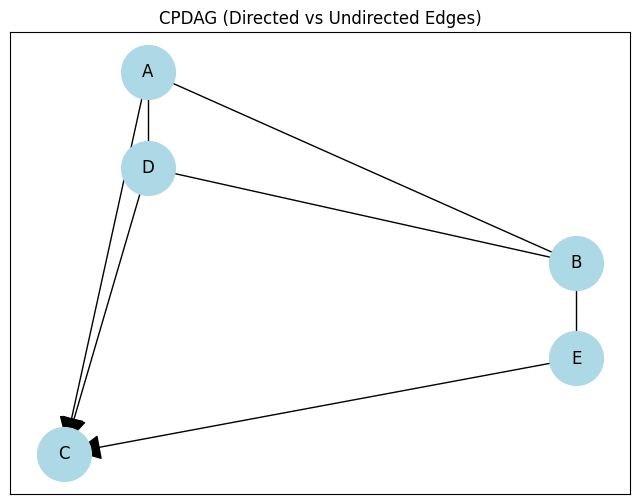

In [4]:
from causallearn.graph.Endpoint import Endpoint
from networkx.drawing.nx_pydot import graphviz_layout

def cpdag_to_nx(cpdag):
    """
    Convert a causal-learn CPDAG into two NetworkX graphs:
    one directed and one undirected
    """
    
    G_dir = nx.DiGraph()
    G_undir = nx.Graph()
    
    # Iterate through CPDAG edges and classify them
    for edge in cpdag.get_graph_edges():
        n1 = edge.get_node1().get_name()
        n2 = edge.get_node2().get_name()
        
        end1 = edge.get_endpoint1()
        end2 = edge.get_endpoint2()
        
        # Case 1: n1 → n2
        if end1 == Endpoint.TAIL and end2 == Endpoint.ARROW:
            G_dir.add_edge(n1, n2)
        
        # Case 2: n2 → n1
        elif end1 == Endpoint.ARROW and end2 == Endpoint.TAIL:
            G_dir.add_edge(n2, n1)
        
        # Case 3: undirected edge (no clear orientation)
        else:
            G_undir.add_edge(n1, n2)
    
    return G_dir, G_undir


# Convert CPDAG into directed and undirected NetworkX graphs
G_dir, G_undir = cpdag_to_nx(cpdag)

# Build a layout graph and add all nodes
G_layout = nx.DiGraph()
G_layout.add_nodes_from(G_dir.nodes())
G_layout.add_nodes_from(G_undir.nodes())

# add all edges (directed is 1, undirected is 2)
G_layout.add_edges_from(G_dir.edges())
G_layout.add_edges_from([(u, v) for u, v in G_undir.edges()])
G_layout.add_edges_from([(v, u) for u, v in G_undir.edges()])


# Initialise plot
plt.figure(figsize=(8, 6))

pos = graphviz_layout(G_layout, prog='dot')

# Draw nodes FIRST
nx.draw_networkx_nodes(G_layout, pos, node_size=1500, node_color="lightblue")

# Undirected edges
nx.draw_networkx_edges(
    G_undir,
    pos,
    edgelist=list(G_undir.edges()),
    width=1.0
)

# Directed edges (visible arrows)
nx.draw_networkx_edges(
    G_dir,
    pos,
    edgelist=list(G_dir.edges()),
    arrows=True,
    arrowsize=40,
    width=1,
)

nx.draw_networkx_labels(G_layout, pos)




# Final plot formatting
plt.title("CPDAG (Directed vs Undirected Edges)")
plt.show()

In [49]:
print("Directed edges:", len(G_dir.edges()))
print("Undirected edges:", len(G_undir.edges()))

Directed edges: 0
Undirected edges: 3
